# Registration sweep + post-hoc analysis (one subject)

This notebook runs several `ptvreg` variants for **one subject** entirely in a **subsampled space** (downsampled once, cached), saves every warped image + warp field into its own folder, then scores each variant by **per-label Dice** between the fixed labels and the moving labels warped into fixed space.

**Workflow**
1. Edit the source paths + experiment scale (cell in §1).
2. Downsample the inputs **once** — cached, so it's free on re-runs (§1b).
3. Edit the parameter grid (§2).
4. Run with `DRY_RUN = True` to preview commands, then flip to `False` and run the sweep.
5. Re-run the analysis cells as often as you like — they only read the small cached outputs.
6. Promote the winning settings to full resolution at the end (§6).

> Kernel: select the interpreter where you `pip install -e .`'d pTVreg (e.g. `~/venvs/pTVreg/bin/python`) so `ptvreg`/`ptvwarp` resolve.

In [1]:
import subprocess
import itertools
from pathlib import Path

import numpy as np
import nibabel as nib
import pandas as pd
import scipy.ndimage as ndimage
from scipy.ndimage import map_coordinates

# ------------------------------------------------------------------
# TOGGLES
# ------------------------------------------------------------------
DRY_RUN       = False    # True = print commands only. False = actually register.
SKIP_EXISTING = False   # True = don't re-register a variant whose warp already exists.

# How to call the tools. 'ptvreg'/'ptvwarp' if they're on PATH for this kernel.
# If not found, use the module form so it always matches this kernel's env:
#   import sys; PTVREG = [sys.executable, '-m', 'pTVreg.cli']
PTVREG  = ["ptvreg"]
PTVWARP = ["ptvwarp"]

## 1. What am I aligning?
Edit these five paths for the subject. `FIXED_LABELS` / `MOVING_LABELS` drive both the soft-Dice guidance during registration **and** the post-hoc scoring.

In [2]:
SUBJECT = "sub-004"
SRC_DIR = Path("/amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/sub-004/features")

# --- full-resolution SOURCES (never modified, never fed straight to ptvreg) ---
SRC_FIXED         = SRC_DIR / "nacpet.nii.gz"                    # -f  (target space)
SRC_MOVING        = SRC_DIR / "mri_combined_sum.nii.gz"          # -m  (gets warped)
SRC_FIXED_LABELS  = SRC_DIR / "nacpet_nnUNetWithBody_MR50.nii.gz"
SRC_MOVING_LABELS = SRC_DIR / "mri_combined_sum_TSWithBody.nii.gz"

RUNS_DIR  = Path("/amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS") / SUBJECT
CACHE_DIR = RUNS_DIR / "_cache"

# The ENTIRE experiment runs in this subsampled space. We downsample the four
# inputs ONCE (next cell) and cache them; every variant then registers, warps
# and scores at this small size -> no per-variant full-res resampling.
EXPERIMENT_SCALE = 0.33

# Labels used to SCORE each variant post-hoc. Include some that are NOT in the
# dice grid below to detect over-fitting to the guided structures.
EVAL_LABELS = [1, 6, 11, 12, 3, 4, 38, 51]

for p in [SRC_FIXED, SRC_MOVING, SRC_FIXED_LABELS, SRC_MOVING_LABELS]:
    print(("ok  " if p.exists() else "MISSING "), p)

ok   /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/sub-004/features/nacpet.nii.gz
ok   /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/sub-004/features/mri_combined_sum.nii.gz
ok   /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/sub-004/features/nacpet_nnUNetWithBody_MR50.nii.gz
ok   /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/sub-004/features/mri_combined_sum_TSWithBody.nii.gz


## 1b. Downsample once, cache, work small

The expensive part is resampling these huge volumes. Do it **exactly once**: build a downsampled copy of the fixed/moving images and their labels, cache them, and point `FIXED`/`MOVING`/`FIXED_LABELS`/`MOVING_LABELS` at the small versions. Every variant then registers with `--scale_factor 1.0` (no further resampling), warps small labels, and scores at this size. Re-running is instant because the cache is reused. Promote the winner to full resolution at the very end.

In [3]:
def downsample_and_cache(src, out, scale, is_label):
    """Downsample a NIfTI by `scale` once and cache it. Labels use nearest-neighbour."""
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists():
        return out
    img = nib.load(str(src))
    data = img.get_fdata()
    order = 0 if is_label else 1
    small = ndimage.zoom(data, scale, order=order)
    if is_label:
        small = np.round(small)
    # Keep physical space consistent: new voxel index n maps to old index n/scale,
    # so the downsampled fixed/moving/labels stay mutually aligned for ptvwarp + Dice.
    new_affine = img.affine @ np.diag([1 / scale, 1 / scale, 1 / scale, 1.0])
    nib.save(nib.Nifti1Image(small.astype(data.dtype), new_affine), str(out))
    print(f"  cached {out.name:20s} {data.shape} -> {small.shape}")
    return out

s = EXPERIMENT_SCALE
print(f"Building experiment space at scale {s} (cached in {CACHE_DIR}) ...")
FIXED         = downsample_and_cache(SRC_FIXED,         CACHE_DIR / "fixed.nii.gz",         s, is_label=False)
MOVING        = downsample_and_cache(SRC_MOVING,        CACHE_DIR / "moving.nii.gz",        s, is_label=False)
FIXED_LABELS  = downsample_and_cache(SRC_FIXED_LABELS,  CACHE_DIR / "fixed_labels.nii.gz",  s, is_label=True)
MOVING_LABELS = downsample_and_cache(SRC_MOVING_LABELS, CACHE_DIR / "moving_labels.nii.gz", s, is_label=True)
print("Experiment space ready. All variants below run at this size.")

Building experiment space at scale 0.33 (cached in /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache) ...
  cached fixed.nii.gz         (512, 512, 531) -> (169, 169, 175)
  cached moving.nii.gz        (512, 512, 531) -> (169, 169, 175)
  cached fixed_labels.nii.gz  (512, 512, 531) -> (169, 169, 175)
  cached moving_labels.nii.gz (512, 512, 531) -> (169, 169, 175)
Experiment space ready. All variants below run at this size.


### Label coverage check
Before sweeping, see which labels actually survive at `EXPERIMENT_SCALE` and are shared by both maps. This grounds both the guidance (`dice_labels`) and the scoring (`EVAL_LABELS`): a label with almost no voxels here won't give a trustworthy Dice.

In [4]:
# Which labels actually survive at EXPERIMENT_SCALE? You can only guide/score
# labels present in BOTH downsampled maps with enough voxels to be meaningful.
fx = np.round(nib.load(str(FIXED_LABELS)).get_fdata()).astype(int)
mv = np.round(nib.load(str(MOVING_LABELS)).get_fdata()).astype(int)
fx_ids = {int(i): int((fx == i).sum()) for i in np.unique(fx) if i != 0}
mv_ids = {int(i): int((mv == i).sum()) for i in np.unique(mv) if i != 0}
shared = sorted(set(fx_ids) & set(mv_ids))

cov = pd.DataFrame([
    {"label": L, "fixed_vox": fx_ids[L], "moving_vox": mv_ids[L], "in_EVAL": L in EVAL_LABELS}
    for L in shared
]).sort_values("fixed_vox", ascending=False).reset_index(drop=True)

missing_eval = [L for L in EVAL_LABELS if L not in shared]
if missing_eval:
    print("WARNING: EVAL_LABELS not shared at this scale (will score NaN):", missing_eval)
print(f"{len(shared)} shared labels at scale {EXPERIMENT_SCALE}. "
      "Labels with few voxels are unreliable — raise EXPERIMENT_SCALE or drop them from EVAL_LABELS.")
cov

49 shared labels at scale 0.33. Labels with few voxels are unreliable — raise EXPERIMENT_SCALE or drop them from EVAL_LABELS.


,label,fixed_vox,moving_vox,in_EVAL
0,1,402105,353574,True
1,6,13245,10146,True
2,51,9939,10801,True
3,12,9264,19706,True
4,11,8156,18285,True
5,42,6672,4881,False
6,20,5424,2184,False
7,14,5008,3198,False
8,23,4507,3655,False
9,48,4330,3259,False


## 2. The variant grid — the parameters that actually matter

With strong multi-organ segmentations, structure alignment is the goal, so the two dominant knobs are:

- **`lambda_reg`** — displacement-field smoothness. Too low → flexible but folds/unrealistic; too high → smooth but under-fits.
- **`dice_weight`** — how hard the label overlap dominates the intensity metric.

They trade off against each other, so we sweep them as a 2D grid. Three deliberate simplifications, justified by the code:

- **Guide on *all* shared labels** (`dice_labels=None`). The Dice loss is a *mean* over labels, so more labels doesn't rescale `dice_weight`; and working small removes the OOM that forced label picking.
- **`lambda_jac` on** — an anti-folding penalty, so we can push `dice_weight` high without tearing anatomy.
- Everything else (`iterations`, `metric`, `spacing`) is held fixed for now; promote to a sweep axis later if the 2D grid plateaus.

In [5]:
# The two knobs that actually move the result:
#   lambda_reg  -> DVF smoothness (data-fit vs realistic deformation)
#   dice_weight -> how hard the segmentations dominate the intensity metric
# Everything else is held fixed here so the sweep is readable.
COMMON = dict(
    scale_factor=1.0,           # inputs are ALREADY downsampled (cache cell) -> no re-resampling
    iterations=300,
    metric="lcc",
    edge=False,                 # True adds -e (align gradient edges)
    # dice_labels=None => guide on ALL shared labels. Affordable now that we work
    # small; the loss is a MEAN over labels, so this does not rescale dice_weight.
    dice_labels=None,
    # Anti-folding guard. Lets us push dice_weight hard without tearing anatomy.
    # 0 = off. Indicative 0.5-5. Watch the fold_% column in the analysis.
    lambda_jac=1.0,
)

# Primary 2D sweep. Keep it small; expand once you see the trend.
GRID = dict(
    lambda_reg=[0.1, 0.2, 0.4],
    dice_weight=[1.0, 3.0, 8.0],
)

def variant_name(v):
    return f"lr{v['lambda_reg']}_dw{v['dice_weight']}"

VARIANTS = []
for combo in itertools.product(*GRID.values()):
    v = {**COMMON, **dict(zip(GRID.keys(), combo))}
    v["name"] = variant_name(v)
    VARIANTS.append(v)

print(f"{len(VARIANTS)} variants (lambda_reg x dice_weight):")
for v in VARIANTS:
    print("  ", v["name"])

9 variants (lambda_reg x dice_weight):
   lr0.1_dw1.0
   lr0.1_dw3.0
   lr0.1_dw8.0
   lr0.2_dw1.0
   lr0.2_dw3.0
   lr0.2_dw8.0
   lr0.4_dw1.0
   lr0.4_dw3.0
   lr0.4_dw8.0


## 3. Run the sweep
For each variant: register (saving `warped.nii.gz` + `warp.nii.gz`), then warp the **moving labels** into fixed space with nearest-neighbour so we can score them.

In [6]:
def build_reg_cmd(v, out_dir):
    cmd = PTVREG + [
        "-f", str(FIXED), "-m", str(MOVING),
        "-o", str(out_dir / "warped.nii.gz"),
        "-w", str(out_dir / "warp.nii.gz"),
        "--scale_factor", str(v["scale_factor"]),
        "--iterations", str(v["iterations"]),
        "--lambda_reg", str(v["lambda_reg"]),
        "--lambda_jac", str(v["lambda_jac"]),
        "--metric", v["metric"],
    ]
    if v.get("edge"):
        cmd += ["-e"]
    cmd += [
        "--fixed-labels", str(FIXED_LABELS),
        "--moving-labels", str(MOVING_LABELS),
        "--dice-weight", str(v["dice_weight"]),
    ]
    if v.get("dice_labels"):   # None => omit => ptvreg uses ALL shared labels
        cmd += ["--dice-labels", *[str(x) for x in v["dice_labels"]]]
    return cmd

def build_warp_labels_cmd(out_dir):
    return PTVWARP + [
        "-i", str(MOVING_LABELS),
        "-r", str(FIXED_LABELS),
        "-w", str(out_dir / "warp.nii.gz"),
        "-o", str(out_dir / "moved_labels.nii.gz"),
        "--interp", "nearest",
    ]

def run(cmd):
    print("  " + " ".join(cmd))
    if not DRY_RUN:
        subprocess.run(cmd, check=True)

print("### DRY RUN ###" if DRY_RUN else "### RUNNING FOR REAL ###")
for v in VARIANTS:
    out_dir = RUNS_DIR / v["name"]
    out_dir.mkdir(parents=True, exist_ok=True)
    warp_path = out_dir / "warp.nii.gz"

    print(f"\n=== {SUBJECT} / {v['name']} ===")
    if SKIP_EXISTING and warp_path.exists() and not DRY_RUN:
        print("  (skipped — warp already exists)")
        continue
    run(build_reg_cmd(v, out_dir))
    run(build_warp_labels_cmd(out_dir))

print("\nDone.")

### RUNNING FOR REAL ###

=== sub-004 / lr0.1_dw1.0 ===
  ptvreg -f /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache/fixed.nii.gz -m /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache/moving.nii.gz -o /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/lr0.1_dw1.0/warped.nii.gz -w /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/lr0.1_dw1.0/warp.nii.gz --scale_factor 1.0 --iterations 300 --lambda_reg 0.1 --lambda_jac 1.0 --metric lcc --fixed-labels /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache/fixed_labels.nii.gz --moving-labels /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache/moving_labels.nii.gz --dice-weight 1.0
Loading fixed: /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache/fixed.nii.gz
Loading moving: /amadeo/DATA/PUBLIC/BIC-MAC/bic-mac-data/val/RUNS/sub-004/_cache/moving.nii.gz
GPU detected and used by default.
Using device: cuda
Loading fixed labels: /amadeo/DATA/PUBLIC/BIC-MAC/bic-ma

## 4. Post-hoc scoring — Dice **and** folding

Two numbers per variant, because Dice alone is misleading:

- **`mean_dice`** — structure overlap after warping (higher = better alignment). `baseline` = no registration, the floor every variant must beat.
- **`fold_%`** — percent of voxels where the Jacobian determinant ≤ 0, i.e. the deformation folds/tears anatomy. A high-Dice result with high `fold_%` is *not* a real alignment.

The best setting is the one with high Dice **and** low folding — see the scatter in §5.

In [7]:
def dice_per_label(a, b, labels):
    out = {}
    for L in labels:
        m1, m2 = (a == L), (b == L)
        denom = m1.sum() + m2.sum()
        out[L] = np.nan if denom == 0 else 2.0 * np.logical_and(m1, m2).sum() / denom
    return out

def resample_labels_to_ref(moving_path, ref_path):
    """Nearest-neighbour resample moving labels onto the ref grid (affine only)."""
    mov = nib.load(str(moving_path))
    ref = nib.load(str(ref_path))
    ref_shape = tuple(ref.shape[:3])
    coords = np.indices(ref_shape, dtype=np.float32).reshape(3, -1)
    hom = np.vstack([coords, np.ones((1, coords.shape[1]))])
    mov_coords = (np.linalg.inv(mov.affine) @ (ref.affine @ hom))[:3]
    vals = map_coordinates(mov.get_fdata(), mov_coords, order=0, mode="nearest")
    return np.round(vals).astype(int).reshape(ref_shape)

def folding_pct(warp_path):
    """% of voxels where det(Jacobian) <= 0 (folding / non-diffeomorphic).
    High Dice with high folding = torn anatomy, not a real alignment."""
    w = nib.load(str(warp_path)).get_fdata()
    if w.ndim == 4 and w.shape[-1] == 3:
        u = np.moveaxis(w, -1, 0)
    elif w.ndim == 4 and w.shape[0] == 3:
        u = w
    else:
        u = np.moveaxis(np.squeeze(w), -1, 0)
    J = np.empty((3, 3) + u.shape[1:], dtype=np.float32)
    for i in range(3):
        gi = np.gradient(u[i])            # d u_i / d x_j for j = 0,1,2
        for j in range(3):
            J[i, j] = gi[j] + (1.0 if i == j else 0.0)
    det = (J[0, 0] * (J[1, 1] * J[2, 2] - J[1, 2] * J[2, 1])
           - J[0, 1] * (J[1, 0] * J[2, 2] - J[1, 2] * J[2, 0])
           + J[0, 2] * (J[1, 0] * J[2, 1] - J[1, 1] * J[2, 0]))
    return float((det <= 0.0).mean() * 100.0)

fixed_lbl = np.round(nib.load(str(FIXED_LABELS)).get_fdata()).astype(int)

rows = []

# Baseline (no registration) — Dice floor, zero folding by definition.
base_lbl = resample_labels_to_ref(MOVING_LABELS, FIXED_LABELS)
d = dice_per_label(fixed_lbl, base_lbl, EVAL_LABELS)
rows.append({"name": "baseline", "lambda_reg": np.nan, "dice_weight": np.nan,
             "mean_dice": np.nanmean(list(d.values())), "fold_%": 0.0,
             **{f"dice_{L}": d[L] for L in EVAL_LABELS}})

# Variants
for v in VARIANTS:
    out_dir = RUNS_DIR / v["name"]
    moved_path = out_dir / "moved_labels.nii.gz"
    warp_path = out_dir / "warp.nii.gz"
    if not moved_path.exists():
        print(f"skip {v['name']}: {moved_path} not found (run the sweep first)")
        continue
    moved_lbl = np.round(nib.load(str(moved_path)).get_fdata()).astype(int)
    d = dice_per_label(fixed_lbl, moved_lbl, EVAL_LABELS)
    rows.append({"name": v["name"], "lambda_reg": v["lambda_reg"], "dice_weight": v["dice_weight"],
                 "mean_dice": np.nanmean(list(d.values())),
                 "fold_%": folding_pct(warp_path) if warp_path.exists() else np.nan,
                 **{f"dice_{L}": d[L] for L in EVAL_LABELS}})

df = pd.DataFrame(rows).sort_values("mean_dice", ascending=False).reset_index(drop=True)
df.round(3)

,name,lambda_reg,dice_weight,mean_dice,fold_%,dice_1,dice_6,dice_11,dice_12,dice_3,dice_4,dice_38,dice_51
0,lr0.1_dw8.0,0.1,8.0,0.860,0.389,0.829,0.918,0.910,0.909,0.793,0.871,0.709,0.945
1,lr0.2_dw8.0,0.2,8.0,0.859,0.384,0.828,0.918,0.908,0.909,0.774,0.872,0.725,0.939
2,lr0.4_dw3.0,0.4,3.0,0.858,0.286,0.831,0.913,0.906,0.905,0.799,0.875,0.723,0.915
3,lr0.4_dw8.0,0.4,8.0,0.857,0.337,0.828,0.916,0.908,0.905,0.788,0.869,0.705,0.935
4,lr0.1_dw1.0,0.1,1.0,0.856,0.252,0.838,0.910,0.902,0.900,0.796,0.866,0.724,0.910
5,lr0.1_dw3.0,0.1,3.0,0.847,0.384,0.823,0.902,0.906,0.911,0.767,0.858,0.719,0.890
6,lr0.2_dw3.0,0.2,3.0,0.847,0.379,0.825,0.910,0.907,0.904,0.764,0.851,0.726,0.886
7,lr0.2_dw1.0,0.2,1.0,0.840,0.260,0.832,0.900,0.888,0.892,0.769,0.850,0.727,0.862
8,lr0.4_dw1.0,0.4,1.0,0.823,0.176,0.822,0.869,0.893,0.861,0.761,0.852,0.733,0.791
9,baseline,NaN,NaN,0.415,0.000,0.729,0.316,0.578,0.595,0.095,0.195,0.588,0.224


## 5. Visualise
Heatmap of per-label Dice (rows = variants, sorted best-first). Labels **not** in a variant's `--dice-labels` are the honest test of generalization.

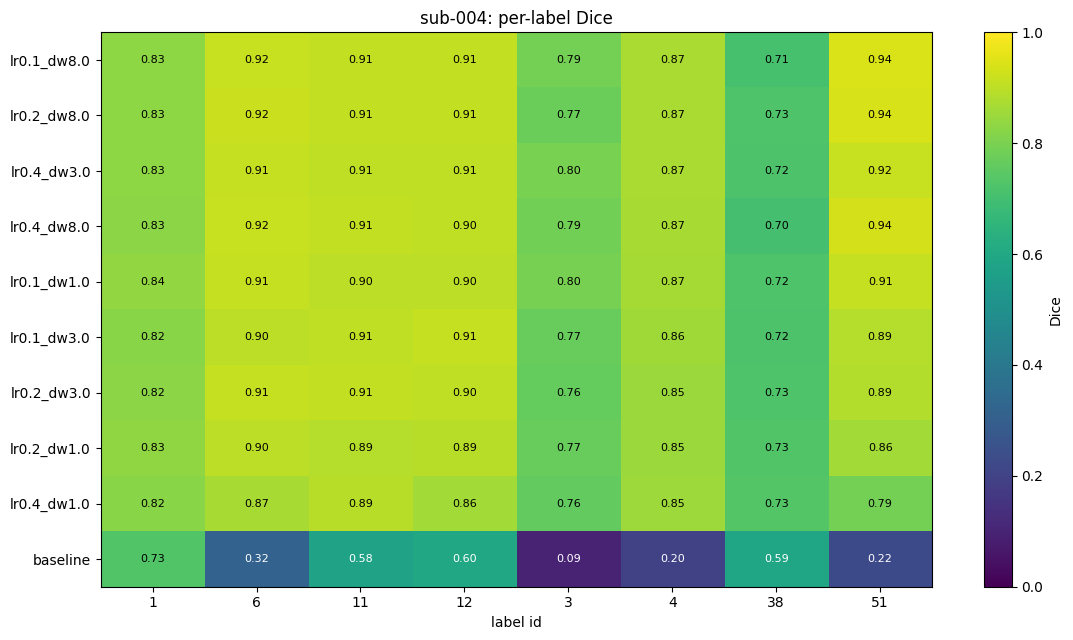

In [8]:
import matplotlib.pyplot as plt

label_cols = [f"dice_{L}" for L in EVAL_LABELS]
mat = df.set_index("name")[label_cols]

fig, ax = plt.subplots(figsize=(1.2 * len(label_cols) + 2, 0.5 * len(mat) + 1.5))
im = ax.imshow(mat.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(label_cols)))
ax.set_xticklabels([str(L) for L in EVAL_LABELS])
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index)
ax.set_xlabel("label id")
ax.set_title(f"{SUBJECT}: per-label Dice")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="Dice")
plt.tight_layout()
plt.show()

In [9]:
# Effect of the two swept knobs on mean Dice (excludes baseline).
piv = df[df["name"] != "baseline"].pivot_table(
    index="lambda_reg", columns="dice_weight", values="mean_dice")
print("mean Dice by lambda_reg (rows) x dice_weight (cols):")
piv.round(3)

mean Dice by lambda_reg (rows) x dice_weight (cols):


dice_weight,1.0,3.0,8.0
lambda_reg,,,
0.1,0.856,0.847,0.860
0.2,0.840,0.847,0.859
0.4,0.823,0.858,0.857


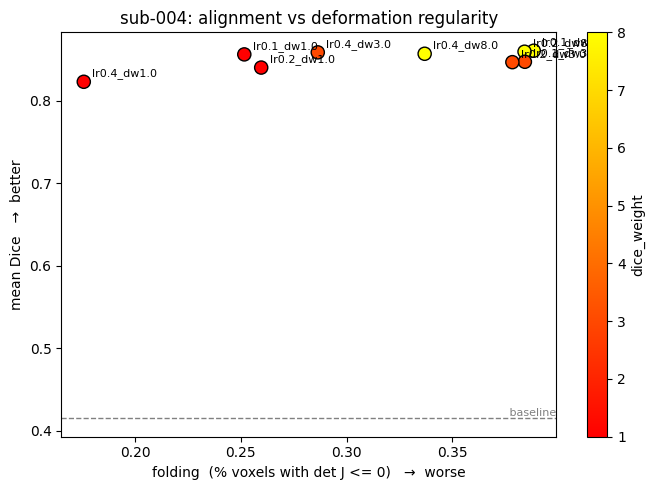

In [10]:
# Dice vs folding — the money plot. Pick a variant in the TOP-LEFT:
# high mean Dice, low fold_%. Points to the right fold anatomy despite high Dice.
import matplotlib.pyplot as plt

plot_df = df[df["name"] != "baseline"]
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(plot_df["fold_%"], plot_df["mean_dice"],
                c=plot_df["dice_weight"], s=90, cmap="autumn", edgecolor="k", zorder=3)
for _, r in plot_df.iterrows():
    ax.annotate(r["name"], (r["fold_%"], r["mean_dice"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
if "baseline" in df["name"].values:
    b = df[df["name"] == "baseline"].iloc[0]
    ax.axhline(b["mean_dice"], ls="--", c="gray", lw=1)
    ax.text(ax.get_xlim()[1], b["mean_dice"], " baseline", va="bottom", ha="right",
            color="gray", fontsize=8)
ax.set_xlabel("folding  (% voxels with det J <= 0)   →  worse")
ax.set_ylabel("mean Dice   →  better")
ax.set_title(f"{SUBJECT}: alignment vs deformation regularity")
fig.colorbar(sc, ax=ax, label="dice_weight")
plt.tight_layout()
plt.show()

## 6. Promote the winner to full resolution

Once the small-space sweep picks a winner, run **that one setting** on the full-resolution sources (`SRC_*`). This is the only full-res registration you pay for. Guarded by `PROMOTE` so it never runs by accident.

In [11]:
PROMOTE     = False   # flip to True to run the final full-res registration
FINAL_SCALE = 0.5     # ptvreg's internal downsample for the final run (inputs are full-res)

best_name = df[df["name"] != "baseline"].iloc[0]["name"]
best = next(v for v in VARIANTS if v["name"] == best_name)
print("Winning variant:", best_name, "->", best)

final_dir = RUNS_DIR / "FINAL" / best_name
final_dir.mkdir(parents=True, exist_ok=True)

final_cmd = PTVREG + [
    "-f", str(SRC_FIXED), "-m", str(SRC_MOVING),
    "-o", str(final_dir / "warped.nii.gz"),
    "-w", str(final_dir / "warp.nii.gz"),
    "--scale_factor", str(FINAL_SCALE),
    "--iterations", str(best["iterations"]),
    "--lambda_reg", str(best["lambda_reg"]),
    "--metric", best["metric"],
]
if best.get("edge"):
    final_cmd += ["-e"]
final_cmd += [
    "--fixed-labels", str(SRC_FIXED_LABELS),
    "--moving-labels", str(SRC_MOVING_LABELS),
    "--dice-weight", str(best["dice_weight"]),
    "--dice-labels", *[str(x) for x in best["dice_labels"]],
]

print(" ".join(final_cmd))
if PROMOTE:
    subprocess.run(final_cmd, check=True)
    print("Full-res warped image:", final_dir / "warped.nii.gz")

Winning variant: lr0.1_dw8.0 -> {'scale_factor': 1.0, 'iterations': 300, 'metric': 'lcc', 'edge': False, 'dice_labels': None, 'lambda_jac': 1.0, 'lambda_reg': 0.1, 'dice_weight': 8.0, 'name': 'lr0.1_dw8.0'}


TypeError: 'NoneType' object is not iterable